# Isogrid Nosecone Calculator
Supports both regular isogrid and open web calculations.
Does not optimize

In this notebook, we'll find the isogrid parameters for the 3D printed Nosecone. The nosecone is built in sections and the isogrid is customized for each section. Section 0 is the base of the nosecone.

### Definitions from Handbook for translating equations
t = thickness of Skin  
b = width of rib web  
d = depth of web  
c = depth of flange  
w = width of flange  
s = t+d = plate thickness of unflanged isogrid  
h = height of triangle  
a = leg of triangle (center to center of nodes)  
kc = column fixity

beta = b/a  (width of rib web/leg of triangle)  


Module Design Parameters:
    Name: Section_0
    Inner Diameter: 6.0625 in
    Skin Thickness: 0.055 in
    Rib Depth: 0.192 in
    Rib Width: 0.032 in
    Number of radial divisions: 15
Module Properties:
    Tbar 0.069
    h 1.350
    a 1.559
    General Instability - 267.9 lbf/in   5425 lbf
    Skin Buckling       - 270.5 lbf/in   5477 lbf
    Rib Cripling        - 273.4 lbf/in   5537 lbf
Rel Weight:  1.0
Rel Strength:  1.0

Module Design Parameters:
    Name: Section_1
    Inner Diameter: 5.86 in
    Skin Thickness: 0.055 in
    Rib Depth: 0.19 in
    Rib Width: 0.032 in
    Number of radial divisions: 15
Module Properties:
    Tbar 0.069
    h 1.307
    a 1.509
    General Instability - 277.4 lbf/in   5438 lbf
    Skin Buckling       - 289.1 lbf/in   5668 lbf
    Rib Cripling        - 279.7 lbf/in   5483 lbf
Rel Weight: 0.976
Rel Strength:  1.0

Module Design Parameters:
    Name: Section_2
    Inner Diameter: 4.736 in
    Skin Thickness: 0.053 in
    Rib Depth: 0.17 in
    Rib 

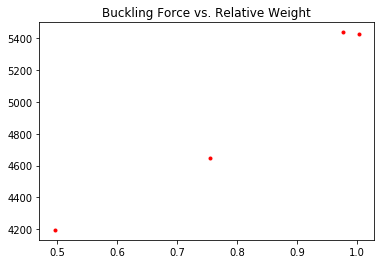

In [55]:
import math
import matplotlib.pyplot as plt

# Material properties 
E = 1.85 # Young's Modules, GPa for Formlabs Nylon 12
E_imp = E*145038 # PSI
nu = 0.33 # Poisson's Ratio for Al 6061-T6
material_name = 'Nylon12'
#F_ty = 40 # ksi (Yield Strength)
F_tu = 7.25 # ksi (Ultimate Strength) 50 MPa for Formlabs Nylon 12

# Instability Coefs
c0 = 0.397    # 4.2.005
c1 = 10.2     # 4.2.006
c2 = 0.616    # 4.2.008

kc = 2.0 # assumed on page 4.9.009

# Common Properties
flanges = False

# Parametric Space
# Inner Diameter, wall_t, rib_depth, rib_width, num_cells, Name
#module_options = [[6.0625,0.1,0.1,0.1,18, 'Initial'],
#                  [6.0625,0.1,0.1,0.05,18, 'Thinner Ribs'],
#                  [6.0625,0.08,0.1,0.05,18, 'Thinner Skin'],
#                  [6.0625,0.07,0.1,0.05,18, 'Thinner Skin2'],
#                  [6.0625,0.07,0.1,0.05,15, 'Less Cells'],
#                  [6.0625,0.07,0.14,0.05,15, 'Taller Ribs'],
#                  [6.0625,0.06,0.14,0.05,15, 'Thinner Skin3'],
#                  [6.0625,0.06,0.14,0.04,15, 'Narrower Ribs'],
#                  [6.0625,0.055,0.192,0.032,15, 'Taller Ribs2']]
module_options = [[6.0625,0.055,0.192,0.032,15, 'Section_0'],
                  [2.93*2.0,0.055,0.19,0.032,15, 'Section_1'],
                  [2.368*2.0,0.053,0.17,0.03,13, 'Section_2'],
                  [1.505*2.0,0.053,0.145,0.03,10, 'Section_3']]

results = []
for module in module_options:
    print() # new line
    module_id = module[0]
    skin_t = module[1]
    rib_depth = module[2]
    rib_width = module[3]
    num_radial_divisions = module[4]
    module_od = module_id+2*rib_depth
    module_r = module_od/2
    rel_weight_data = []
    pattern_size = module_od*math.pi/num_radial_divisions
    cell_height = pattern_size
    a = 2*cell_height/(3**0.5)

    print('Module Design Parameters:')
    print(f'    Name: {module[-1]}')
    print(f'    Inner Diameter: {module[0]} in')
    print(f'    Skin Thickness: {module[1]} in')
    print(f'    Rib Depth: {module[2]} in')
    print(f'    Rib Width: {module[3]} in')
    print(f'    Number of radial divisions: {module[4]}')

    print('Module Properties:')
    if skin_t == 0.0:
        # Open Web
        # Check that rib depth > rib_width (d>b)
        if rib_depth > rib_width:
            print('    PASS - Rib shape acceptable (depth > width)')
        else:
            print('    FAIL - Rib depth needs to be greater than rib width')
        E_bar = E_imp*rib_width/a
        t_bar = 3*rib_width*rib_depth/cell_height
        beta = rib_width/a
        N_cr_1 = 0.612*c0*E_imp*(rib_width*rib_depth*rib_depth)/(module_r*cell_height) # Eqn 4.9.8 (Rectangular Stiffeners)
        N_cr_2 = 1.422*kc*E_imp*rib_depth*(beta**3) # Eqn 4.9.10
        
        F_cr_1 = N_cr_1*2*math.pi*module_r
        F_cr_2 = N_cr_2*2*math.pi*module_r
        strength = min(F_cr_1,F_cr_2)
    
        print(f'    Tbar {t_bar:.3f}')
        print(f'    Beta {beta:.3f}')
        print(f'    E_star {E_bar:.3e}')
        print('    General Instability - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_1,F_cr_1))
        print('    Rib Cripling        - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_2,F_cr_2))
    else:
        # Closed Web
        alpha = (rib_width*rib_depth)/(skin_t*cell_height) # Web non-dimensional ratio, pg. 2.0.008
        delta = rib_depth/skin_t # rib depth to skin thickness ratio, pg. 2.0.008
        if flanges == False:
            beta = (3*alpha*(1+delta)**2+(1+alpha)*(1+alpha*delta**2))**0.5
            t_star = skin_t*beta/(1+alpha) # equivilent thickness, Eq. 2.5.3
            t_bar = skin_t*(1+3*alpha)
            E_star = E*(1+alpha)**2.0/beta # equivilent Young's Modulus Eq. 2.5.4#
        N_cr_1 = c0*E_imp*skin_t*skin_t/module_r*beta
        N_cr_2 = c1*E_imp*skin_t*(1+alpha)*(skin_t*skin_t)/(pattern_size*pattern_size)
        N_cr_3 = c2*E_imp*skin_t*(1+alpha)*(rib_width*rib_width)/(rib_depth*rib_depth)
    
        F_cr_1 = N_cr_1*2*math.pi*module_r
        F_cr_2 = N_cr_2*2*math.pi*module_r
        F_cr_3 = N_cr_3*2*math.pi*module_r
        strength = min(F_cr_1,F_cr_2,F_cr_3)
    
        print(f'    Tbar {t_bar:.3f}')
        print(f'    h {cell_height:.3f}')
        print(f'    a {a:.3f}')
        print('    General Instability - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_1,F_cr_1))
        print('    Skin Buckling       - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_2,F_cr_2))
        print('    Rib Cripling        - {:4.1f} lbf/in {:6.0f} lbf'.format(N_cr_3,F_cr_3))
            
    cs_area = t_bar*2*math.pi*(module_r+t_bar/2)
    if skin_t == 0.0:
        # Note: We add the weight of skin to the weight
        cs_area = (t_bar+0.016)*2*math.pi*(module_r+t_bar/2)
    #rel_w = cs_area/0.513412
    rel_w = cs_area/1.40
    rel_s = strength/5425
    print('Rel Weight: {:4.3}'.format(rel_w))
    print('Rel Strength: {:4.3}'.format(rel_s))
    rel_weight_data.append(rel_w)
    results.append([module_id, rel_w, strength])

# Buckling
buckling_plot = plt.figure(1)
plt.title('Buckling Force vs. Relative Weight')
for item in results:
    plt.plot(item[1], item[2], 'r.', label='id_'+str(item[0]))
#plt.legend()

